# Sanity checks

In [1]:
import sys
sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("../styles/paper.mplstyle")

from source.utils import set_seed, read_csv
from source.system import SystemParams, compute_prices, system_dynamics
from source.policy import PolicyNet, build_policy_input
from source.stochastic_processes import (
    arrivals_departures, innovations,
    SARIMAProcess, make_price_function
)

## Arrivals and departures

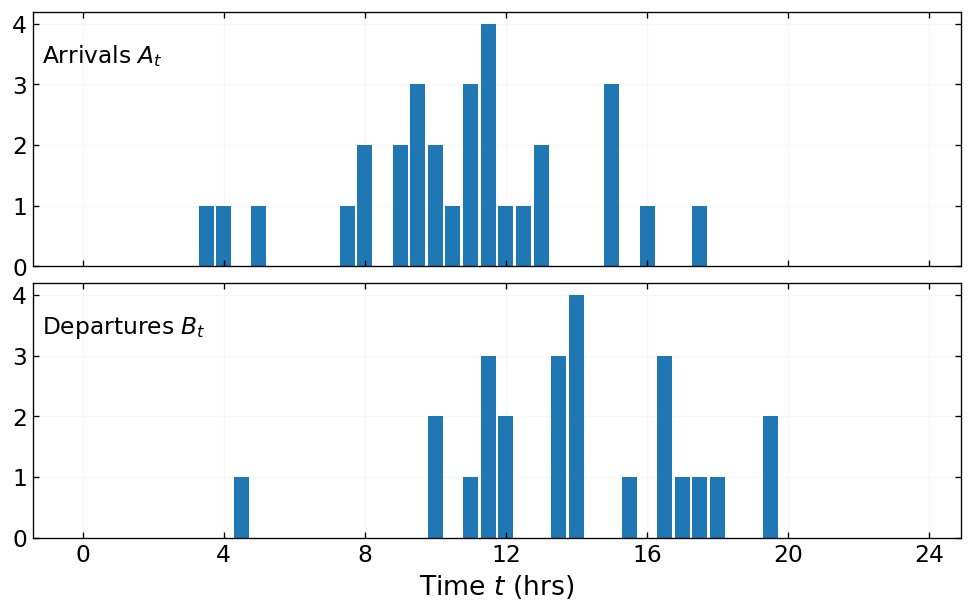

In [2]:
# Time grid
dt = 0.5
t_grid = torch.arange(0, 24, dt)

# Simulation settings
batch = 1
phi = 0.08
N0 = 0

S_t = torch.zeros(batch, 4)
S_t[:, 0] = N0   # idx_n = 0

A_hist = []
B_hist = []
N_hist = []

for t in t_grid:
    A_t, B_t = arrivals_departures(t=t,S_t=S_t,dt=dt,phi=phi,stochastic=True,idx_n=0)

    # Save
    A_hist.append(A_t.item())
    B_hist.append(B_t.item())
    N_hist.append(S_t[:, 0].item())

    # Update parked EVs
    S_t[:, 0] = torch.clamp(S_t[:, 0] + A_t - B_t, min=0)

A_hist = np.array(A_hist)
B_hist = np.array(B_hist)
N_hist = np.array(N_hist)
t_np = t_grid.numpy()

fig, ax = plt.subplots(2, 1, sharex=True)

ax[0].bar(t_np, A_hist, width=dt*0.85)
ax[0].text(0.01, 0.8, r'Arrivals $A_t$', transform=ax[0].transAxes, fontsize=14)

ax[1].bar(t_np, B_hist, width=dt*0.85)
ax[1].text(0.01, 0.8, r'Departures $B_t$', transform=ax[1].transAxes, fontsize=14)

ax[1].set_xticks(np.arange(0, 25, 4))
ax[1].set_xlabel(r'Time $t$ (hrs)')

plt.tight_layout(pad=0.2, h_pad=0.1, w_pad=0.2)
plt.savefig("../figures/arrivals_departures.pdf", bbox_inches="tight")
plt.show()

In [3]:
# --------------------------
# Example: arrivals and departures
# --------------------------

g = set_seed(123)
A_t, B_t = arrivals_departures(
    S_t=S_t, t=12.0, dt=0.5, phi=0.2, rng=g,
    mu=10.77, sigma=3.32, scale=40.0
)

t = torch.tensor(0.5)
e_t = innovations(t.expand(S_t.shape[0]))

# Number of EVs dynamic
N_next = (S_t[:, 0] + A_t - B_t).clamp(min=0.0)

print(f'Arr: {A_t},\nDep: {B_t},\nParked: {N_next}')
print(f'Innovations: {e_t}')

Arr: tensor([1.]),
Dep: tensor([1.]),
Parked: tensor([5.])
Innovations: tensor([-0.0531])


## SARIMA price process

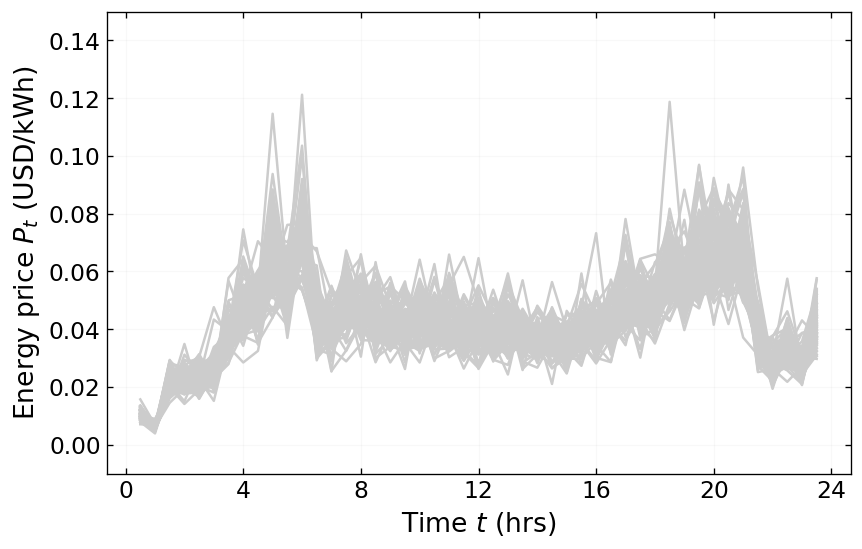

In [4]:
params = SystemParams()

T = 24
energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:T]
future_price = energy_prices[T:]
next_price_function = make_price_function(price_history, future_price, params)

batch = 100
dt = 0.5
P_hats = []
for t in torch.arange(dt, 24, dt):
    t_batch = t.expand(batch)
    eps = innovations(t_batch)
    mu_hat = next_price_function()
    P_hat = torch.exp(torch.log(mu_hat) + eps)
    P_hats.append(P_hat)
P_hats = torch.stack(P_hats)

plt.plot(torch.arange(dt, 24, dt).numpy(), P_hats.numpy() * 0.001, c='0.8')
plt.xticks(torch.arange(0, 24.5, 4))
plt.ylim(-0.01, 0.15)
plt.xlabel("Time $t$ (hrs)")
plt.ylabel("Energy price $P_t$ (USD/kWh)")
plt.show()

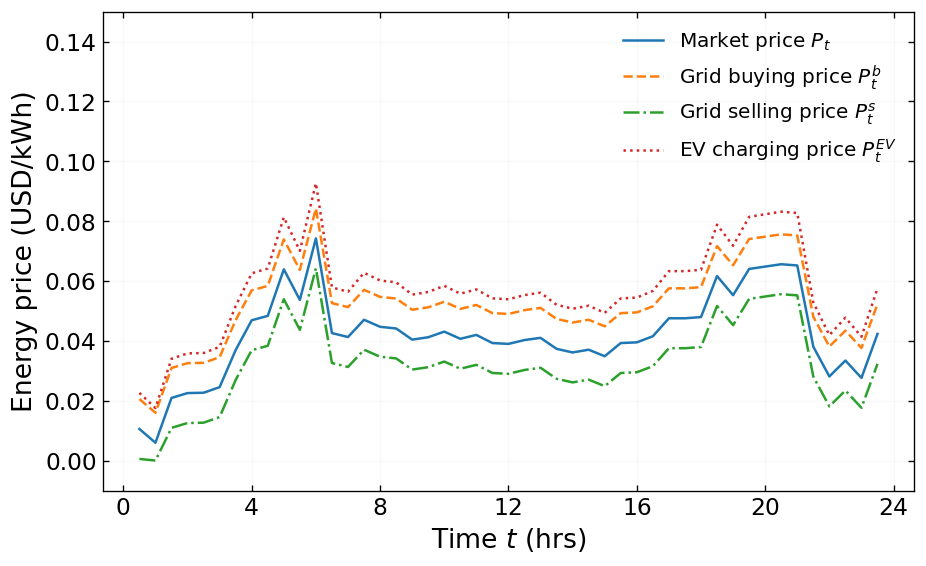

In [5]:
T = params.T
dt = params.dt
rho = params.rho
kappa = params.kappa



next_price_function = make_price_function(price_history, future_price, params)

t_plot = torch.arange(dt, T, dt)

P_market = []

for t in t_plot:
    mu_hat = next_price_function()
    P_market.append(mu_hat)

P_market = torch.stack(P_market) * 0.001  # USD/MWh -> USD/kWh

Pb, Ps, PEV = compute_prices(P_market, rho=rho, kappa=kappa)

fig, ax = plt.subplots()

ax.plot(t_plot.numpy(), P_market.detach().numpy(), label=r"Market price $P_t$", linestyle="-")
ax.plot(t_plot.numpy(), Pb.detach().numpy(), label=r"Grid buying price $P_t^b$", linestyle="--")
ax.plot(t_plot.numpy(), Ps.detach().numpy(), label=r"Grid selling price $P_t^s$", linestyle="-.")
ax.plot(t_plot.numpy(), PEV.detach().numpy(), label=r"EV charging price $P_t^{EV}$", linestyle=":")

ax.set_xticks(np.arange(0, T+1, 4))
ax.set_ylim(-0.01, 0.15)
ax.set_xlabel(r"Time $t$ (hrs)")
ax.set_ylabel(r"Energy price (USD/kWh)")

ax.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.savefig("../figures/forecasted_prices.pdf", bbox_inches="tight")
plt.show()

## Policy input and output

In [6]:
# --------------------------
# Example: policy
# --------------------------
device = torch.device("cpu")

params = SystemParams()
policy = PolicyNet() # NN without training: theta choose at random

t = 10.0
S_t = torch.tensor([
 # N,  D,  E,   P
    [5.,  0., 0., 0.1],
    [0.,  0., 0., 0.1],
    [10., 0., 0., 0.1],
    [2.,  0., 0., 0.1],
])

input = build_policy_input(t=t, S=S_t, params=params)

u_t, _ = policy(input) # S_t passes throught all NN without training
print(t, S_t, input, u_t, sep="\n")

10.0
tensor([[ 5.0000,  0.0000,  0.0000,  0.1000],
        [ 0.0000,  0.0000,  0.0000,  0.1000],
        [10.0000,  0.0000,  0.0000,  0.1000],
        [ 2.0000,  0.0000,  0.0000,  0.1000]])
tensor([[ 0.5000, -0.8660,  0.1667,  0.0000,  0.0000,  0.2000],
        [ 0.5000, -0.8660,  0.0000,  0.0000,  0.0000,  0.2000],
        [ 0.5000, -0.8660,  0.3333,  0.0000,  0.0000,  0.2000],
        [ 0.5000, -0.8660,  0.0667,  0.0000,  0.0000,  0.2000]])
tensor([[0.4883, 0.0697, 0.4999],
        [0.4876, 0.0726, 0.4998],
        [0.4891, 0.0669, 0.5001],
        [0.4879, 0.0714, 0.4998]], grad_fn=<StackBackward0>)


## System dynamics

In [7]:
# -------------------------------
# Example: System Dynamics
# -------------------------------

params = SystemParams()
policy = PolicyNet()

next_price_function = make_price_function(price_history, future_price, params)

t_k = 12


S_t = torch.tensor([
    [5.,  20., 50., 0.1],
    [0.,  10., 30., 0.1],
    [10., 40., 80., 0.1],
], dtype=torch.float32, device=device)

input = build_policy_input(t_k, S_t, params)

u_t, _ = policy(input)

A_t, B_t = arrivals_departures(
    S_t=S_t, t=t_k, dt=params.dt, phi=params.phi,
    stochastic=True, rng=g,
    mu=10.77, sigma=3.32, scale=40.0
)

e_t = innovations(torch.tensor(t_k).expand(S_t.shape[0]))

S_next, c_t, endog = system_dynamics(
    S_t=S_t, u_t=u_t, t=t_k, params=params,
    A_t_override=A_t, B_t_override=B_t, e_t_override=e_t,
    next_price_fn=next_price_function
)
print("S_next =\n", S_next)
print("endog =\n", endog)
print("c_t =\n", c_t)

S_next =
 tensor([[5.0000e+00, 3.0525e+01, 9.8183e+01, 7.5950e-03],
        [3.0000e+00, 8.5000e+01, 8.1638e+01, 1.0597e-02],
        [1.0000e+01, 3.9880e+01, 1.2480e+02, 1.1767e-02]],
       grad_fn=<StackBackward0>)
endog =
 tensor([[20.9493, 48.1833,  0.0000, 58.6579,  0.0000],
        [ 0.0000, 51.6383,  0.0000, 51.6383,  0.0000],
        [42.2398, 44.8012,  0.0000, 65.9211,  0.0000]],
       grad_fn=<StackBackward0>)
c_t =
 tensor([5.1849, 5.6802, 4.6958], grad_fn=<SubBackward0>)
